In [1]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
import math
import pyswip
import qlpp_to_qasm
from qiskit import qasm3
from qiskit import * 
from qiskit_aer import AerSimulator
from mqt.ddsim import DDSIMProvider
from qiskit.circuit.library import MCXVChain
from qiskit.transpiler.passes import RemoveBarriers
from qiskit.visualization import plot_histogram
from IPython.display import display
%matplotlib inline

In [2]:
### --- CONFIG --- ###

## BOARD ##

# board dim
N = 4

## ----- ##


## PROLOG ##

# prolog file
prolog_filename = "nqueens_problem.pl"

# prolog query
prolog_query = f"nqueens_problem({N},C)."

## ------ ##


## QASM ##

# save-to-qasm flag
save_to_qasm = True

# load-from-qasm flag
load_from_qasm = False

# qasm filename
qasm_filename = "nqueens_problem.qasm"

## ---- ##


## PLOT ##

# draw circuit
draw_circuit = False

## ---- ##


## PARAMS ##

# sizing
#
# register
queen_dim = int(math.ceil(math.log2(N)))
state_dim = queen_dim * N
checks_dim = N*(N-1)//2
aux_dim = checks_dim - 3
dim = queen_dim + state_dim + checks_dim + aux_dim + 1
print("Register size:", dim)
#
# diffuser
diffuser_aux_dim = state_dim - 3
diffuser_dim = state_dim + diffuser_aux_dim
#
# search space
S = 2**state_dim

# binding
#
# oracle
oracle_list = [*range(dim)]
#
# diffuser
diffuser_list = None
if diffuser_aux_dim <= aux_dim:  
    diffuser_list = [
        *range(state_dim), 
        *range(state_dim + queen_dim, 
               state_dim + queen_dim + diffuser_aux_dim)]
else:
    diffuser_list = [
        *range(state_dim), 
        *range(state_dim + queen_dim, state_dim + queen_dim + aux_dim), 
        *range(state_dim + queen_dim + aux_dim + 1, 
               state_dim + queen_dim + diffuser_aux_dim + 1)]

# solutions count
solution_map = {1: 1, 2: 0, 3: 0, 4: 2, 5: 10, 6: 4, 7: 40, 8: 92, 9: 352, 10: 724, 
                11: 2680, 12: 14200, 13: 73712, 14: 365596, 15: 2279184, 
                16: 14772512, 17: 95815104, 18: 666090624, 19: 4968057848, 
                20: 39029188884, 21: 314666222712, 22: 2691008701644, 
                23: 24233937684440, 24: 227514171977364, 
                25: 2207893435808352, 26: 22317699616364044, 
                27: 234907967154122528}
M = solution_map.get(N, "Mapping not found.")

# initial angle of solution states
teta_i = math.asin(math.sqrt(M/S))

# iterations
iterations = None
k_target = -1   # (-1 for the use of p_target)
p_target = 1.0  # (1.0 for optimal iterations)
if (k_target == -1):
    iterations = round(math.asin(math.sqrt(p_target)) / 
                       (2 * teta_i) - 0.5)
else:
    iterations = k_target
print("Iterations:", iterations)

# final angle of solution states
teta_f = (2*iterations + 1) * teta_i

# success probability
p_success = math.sin(teta_f) ** 2
print(f"Success probability: {p_success:.2%}")

# shots
shots_target = 32768 # (-1 for the empirical minimum)
shots = None
if shots_target == -1:
    shots = math.ceil(25*M/p_success)
else:
    shots = shots_target
print("Shots:", shots)

# post-processing (if N is not a power of 2)
post_processing = False
if not ((N & (N - 1)) == 0):
    post_processing = True

## ------ ##

Register size: 20
Iterations: 8
Success probability: 99.56%
Shots: 32768


In [3]:
### --- QUERY PROLOG --- ###
def query_prolog():
    prolog = pyswip.Prolog()
    prolog.consult(prolog_filename)
    solution = next(prolog.query(prolog_query), None)

    if solution is not None:
        return solution   
    else:
        print("Nessuna soluzione trovata")
        return None

In [4]:
### --- ORACLE --- ###
def oracle():

    # load qasm file
    if load_from_qasm:
        oracle_qc = qasm3.load(qasm_filename)

    # generate qasm code
    else:

        # prolog query answer
        solution = query_prolog()

        # qlpp circuit
        qlpp_circuit = solution["C"]

        # qlpp -> qasm conversion
        qasm_code = qlpp_to_qasm.get_string(qlpp_circuit=qlpp_circuit, barriers=True)

        # save qasm file
        if save_to_qasm:
            with open(qasm_filename, "w", encoding="utf-8") as f:
                f.write(qasm_code)

        # qasm -> QuantumCircuit conversion
        oracle_qc = qasm3.loads(qasm_code)
        
    return oracle_qc

In [5]:
### --- DIFFUSER --- ###
def diffuser(dif_qc):
    dif_qc.h(range(state_dim))
    dif_qc.x(range(state_dim))

    dif_qc.barrier(range(state_dim))

    dif_qc.h(state_dim-1)
    dif_qc.compose(MCXVChain(num_ctrl_qubits=state_dim-1), range(diffuser_dim), inplace=True)
    dif_qc.h(state_dim-1)

    dif_qc.barrier(range(state_dim))

    dif_qc.x(range(state_dim))
    dif_qc.h(range(state_dim))

    return dif_qc

In [6]:
### --- N-QUEENS PROBLEM --- ###
def nqueens_problem():
    
    # circuit
    qc = QuantumCircuit(QuantumRegister(state_dim,'q'), 
                        QuantumRegister(queen_dim,'xor'), 
                        QuantumRegister(aux_dim,'aux'), 
                        QuantumRegister(1,'ovfl'), 
                        QuantumRegister(checks_dim,'tgt'), 
                        ClassicalRegister(state_dim,'cbits'))

    # H on state register
    qc.h(qc.qregs[0])

    # X on xor and ovfl registers
    qc.x(qc.qregs[1][:] + qc.qregs[3][:])

    qc.barrier()
    
    # oracle
    oracle_qc = oracle()
    oracle_gate = RemoveBarriers()(oracle_qc).to_gate(label='          ORACLE          ')

    # diffuser
    dif_qc = diffuser(QuantumCircuit(diffuser_dim))
    dif_gate = RemoveBarriers()(dif_qc).to_gate(label='          DIFFUSER          ')

    # iterations
    for i in range(iterations):
        if i == 0:
            qc.compose(oracle_qc, oracle_list, inplace=True)
            qc.barrier()
            qc.compose(dif_qc, diffuser_list, inplace=True)
        else:
            qc.compose(oracle_gate, oracle_list, inplace=True)
            qc.barrier()
            qc.compose(dif_gate, diffuser_list, inplace=True)
        
        qc.barrier()
    
    # measurement
    qc.measure(range(state_dim), range(state_dim))

    return qc


qc = nqueens_problem()

if draw_circuit:
    display(qc.draw('mpl', style={'fontsize':18, 'subfontsize':13, 'gatetextcolor':'black'}, fold=max(70, qc.depth()//5), scale=max(0.5, 1.0 - qc.depth()/3000)))

In [7]:
### --- EXECUTION (QASM simulation) --- ###
def execution(qc, shots=1024):
    backend = None
    qc_compiled = None
    if N == 4:
        backend = AerSimulator()
        qc_compiled = transpile(RemoveBarriers()(qc),optimization_level=3,basis_gates=['u1', 'u2', 'u3', 'x', 'cx', 'h', 's', 'sdg', 't', 'tdg'],seed_transpiler=42)
    else:
        backend = DDSIMProvider().get_backend('qasm_simulator')
        qc_compiled = transpile(RemoveBarriers()(qc),backend=backend,optimization_level=3,seed_transpiler=42)
    print("Depth:", qc_compiled.depth())
    print("Gates:", qc_compiled.count_ops())

    job = backend.run(qc_compiled, shots=shots, seed_simulator=42)
    result = job.result()
    counts = result.get_counts()

    return counts


counts = execution(qc, shots)

Depth: 11778
Gates: OrderedDict([('cx', 8368), ('tdg', 3379), ('t', 3291), ('u2', 715), ('h', 417), ('u3', 296), ('u1', 256), ('x', 106), ('measure', 8)])


In [8]:
### --- FILTER (post-processing case) --- ###
def filter(counts):
    valid_counts = {}
    is_valid = True
    
    for bitstring, count in counts.items():
        bitstring = bitstring[::-1]
        columns = []
        for i in range(0, state_dim, queen_dim):
            col = bitstring[i:i+queen_dim]
            if int(col[::-1], 2) >=N:
                is_valid = False
                break
            else:
                columns.append(col) 
        if is_valid:
            valid_bitstring = ''.join(columns)[::-1]
            valid_counts[valid_bitstring] = count
        else:
            is_valid = True
    
    return valid_counts


if post_processing:
    counts = filter(counts)

In [9]:
### --- SNR EVALUATION --- ###
def snr_evaluation(signal_count, shots, S):
    p_signal = signal_count/shots
    p_signal_avg = p_signal/M
    p_noise = 1 - p_signal
    p_noise_avg = p_noise/(S - M)
    snr = p_signal_avg/(p_noise_avg + 1e-15)

    return snr


# solution outputs count
signal_count = sum(sorted(counts.values(), reverse=True)[:M])

# SNR
snr = snr_evaluation(signal_count, shots, S)
snr_db = 10*math.log10(snr)
print(f"SNR: {snr:.3f} ({snr_db:.3f} dB)")

# SNR post-filter
if post_processing:
    shots_filt = sum(counts.values())
    S_filt = N**N
    snr_filt = snr_evaluation(signal_count, shots_filt, S_filt)
    snr_filt_db = 10*math.log10(snr_filt)
    print(f"SNR post-filter: {snr_filt:.3f} ({snr_filt_db:.3f} dB)")

SNR: 28182.769 (44.500 dB)


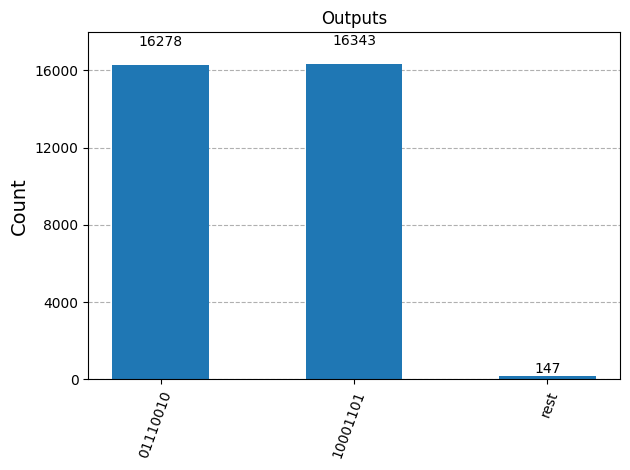

In [10]:
### --- PLOT HISTOGRAM --- ###
plot_histogram(counts, number_to_keep=M, title='Outputs')

In [11]:
### --- PRINT BOARDS --- ###
def print_boards(counts):
    solutions = sorted(counts, key=counts.get, reverse=True)[:M]

    for i, solution in enumerate(solutions):  
        columns = [int(solution[-state_dim:][j:j+queen_dim], 2) for j in range(0, state_dim, queen_dim)][::-1]
        print(f"\nSolution {i+1}: {columns}\n")
        
        for r in range(N):
            line = " ".join("♛" if columns[r] == c else "·" for c in range(N))
            print(f"| {line} |")
        print()


print_boards(counts)


Solution 1: [1, 3, 0, 2]

| · ♛ · · |
| · · · ♛ |
| ♛ · · · |
| · · ♛ · |


Solution 2: [2, 0, 3, 1]

| · · ♛ · |
| ♛ · · · |
| · · · ♛ |
| · ♛ · · |

